In [ ]:
!apt-get update -qq
!apt-get install -y -qq swig ffmpeg xvfb
!pip install -q "gymnasium[box2d]" stable-baselines3[extra] moviepy

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

from IPython.display import HTML, display
from base64 import b64encode

from gymnasium.wrappers import RecordVideo
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

print("Imports OK")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package swig4.0.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubuntu1_all.deb ...
Unpacking swig (4.0.2-1ubuntu1) ...
Setting up swig4.0 (4.0.2-1ubuntu1) ...
Setting up swig (4.0.2-1ubuntu1) ...
Processing triggers for man-db (2.10.2-1) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 14.3 MB/s eta 0:00:00
Imports OK


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# 🏎️ Phase 1 — Perception de l'environnement (CNN)
## NRLE822 · Version Apprenant

**Objectifs :** CNN, fonctions d'activation, feature maps, évaluation

> 🔧 Complétez les cellules marquées `# TODO`

In [ ]:
# TODO : Fixer les seeds (numpy et torch) pour la reproductibilité
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE} | PyTorch {torch.__version__} | Gym {gym.__version__}')

Device : cpu | PyTorch 2.11.0+cpu | Gym 1.3.0


## 1. Découverte de l'environnement

In [ ]:
env = gym.make('CarRacing-v3', render_mode=None, continuous=True)
print('Observation :', env.observation_space)
print('Action      :', env.action_space)

obs, info = env.reset(seed=42)
print('Forme obs :', obs.shape)

Observation : Box(0, 255, (96, 96, 3), uint8)
Action      : Box([-1.  0.  0.], 1.0, (3,), float32)
Forme obs : (96, 96, 3)


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


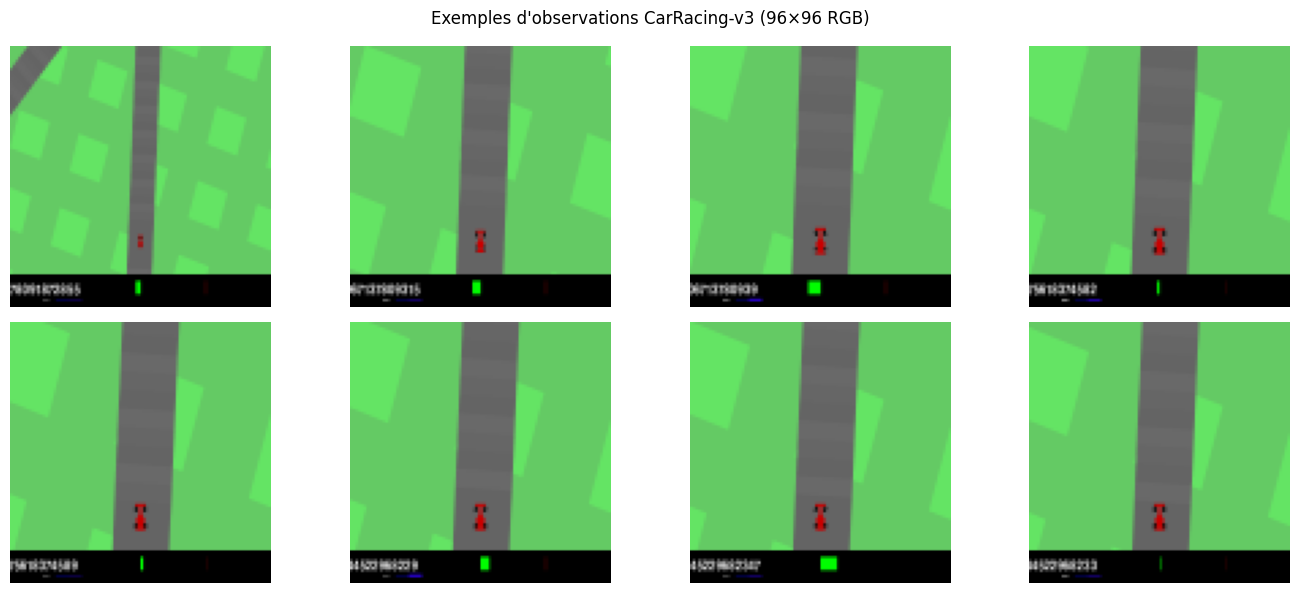

In [ ]:
# TODO : Visualisez 8 frames de l'environnement
# Astuce : utilisez env.step(env.action_space.sample()) pour avancer
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
obs, _ = env.reset(seed=SEED)
for ax in axes.flat:
    for _ in range(20):
        action = env.action_space.sample()
        obs, r, term, trunc, _ = env.step(action)
        if term or trunc:
            obs, _ = env.reset()
    ax.imshow(obs)
    ax.axis('off')
plt.suptitle('Exemples d\'observations CarRacing-v3 (96×96 RGB)', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Fonctions d'activation

*Expliquez dans cette cellule la différence entre ReLU et Sigmoid.*

Réponse : ...

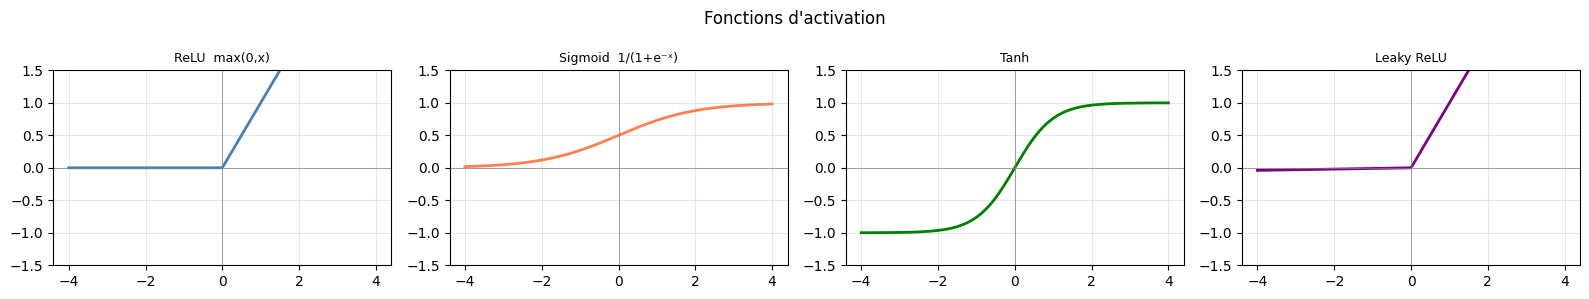

→ ReLU est le choix par défaut dans les CNNs : rapide, pas de saturation pour x>0


In [ ]:
# TODO : Tracez les 4 fonctions d'activation (ReLU, Sigmoid, Tanh, Leaky ReLU)
# x = np.linspace(-4, 4, 200)
x = np.linspace(-4, 4, 200)
acts = {
    'ReLU  max(0,x)': lambda x: np.maximum(0, x),
    'Sigmoid  1/(1+e⁻ˣ)': lambda x: 1/(1+np.exp(-x)),
    'Tanh': np.tanh,
    'Leaky ReLU': lambda x: np.where(x>0, x, 0.01*x)
}
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (name, fn), c in zip(axes, acts.items(), ['steelblue','coral','green','purple']):
    ax.plot(x, fn(x), color=c, lw=2)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(name, fontsize=9); ax.set_ylim(-1.5, 1.5); ax.grid(alpha=0.3)
plt.suptitle('Fonctions d\'activation', fontsize=12); plt.tight_layout(); plt.show()
print('→ ReLU est le choix par défaut dans les CNNs : rapide, pas de saturation pour x>0')

## 3. Architecture CNN

In [ ]:
class PerceptionCNN(nn.Module):
    """
    CNN de perception CarRacing-v3.
    Entrée : (batch, 3, 96, 96) — RGB normalisé [0,1]
    Sortie : (batch, 3)          — logits [tout droit, virage G, virage D]
    """
    def __init__(self, n_classes=3):
        super().__init__()
        # Conv1 : 3→8 filtres 8×8 stride 4  → sortie (8, 23, 23)
        self.conv1 = nn.Conv2d(3, 8, kernel_size=8, stride=4)
        self.bn1   = nn.BatchNorm2d(8)
        # Conv2 : 8→16 filtres 4×4 stride 2  → sortie (16, 10, 10)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=4, stride=2)
        self.bn2   = nn.BatchNorm2d(16)
        # Conv3 : 16→32 filtres 3×3 stride 1 → sortie (32, 8, 8)
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, stride=1)
        self.bn3   = nn.BatchNorm2d(32)
        # Tête FC : 32*8*8 → 128 → n_classes
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.3)  # Régularisation : désactive 30% des neurones
        self.fc1 = nn.Linear(32*8*8, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.flatten(x)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        return self.fc2(x)  # Pas de softmax → inclus dans CrossEntropyLoss

    def get_conv3_features(self, x):
        """Feature maps après Conv3 (pour visualisation)."""
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return F.relu(self.bn3(self.conv3(x)))

model = PerceptionCNN().to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nParamètres : {total:,} (vs {96*96*3*128:,} pour un MLP)')

PerceptionCNN(
  (conv1): Conv2d(3, 8, kernel_size=(8, 8), stride=(4, 4))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(8, 16, kernel_size=(4, 4), stride=(2, 2))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)

Paramètres : 271,019 (vs 3,538,944 pour un MLP)


In [ ]:
# Vérification : ne modifiez pas cette cellule
model = PerceptionCNN(n_classes=3)
dummy = torch.zeros(4, 3, 96, 96)
with torch.no_grad():
    out = model(dummy)
print(f'Entrée {dummy.shape} → Sortie {out.shape}')  # Attendu : torch.Size([4, 3])

Entrée torch.Size([4, 3, 96, 96]) → Sortie torch.Size([4, 3])


## 4. Dataset et entraînement

In [13]:
# TODO : Collectez ~1200 frames et créez les DataLoaders
# Labels : 0=tout droit, 1=virage gauche, 2=virage droite
# N'oubliez pas le split 70/15/15 AVANT de mélanger
class CarFrameDataset(Dataset):
    def __init__(self, frames, labels):
        # (N,H,W,C) → (N,C,H,W) pour PyTorch + normalisation
        self.x = torch.tensor(frames.transpose(0,3,1,2), dtype=torch.float32) / 255.
        self.y = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i]

def collect_frames(n=1200):
    e = gym.make('CarRacing-v3', render_mode=None, continuous=True)
    obs, _ = e.reset(seed=SEED)
    frames, labels = [], []
    for i in range(n + 50):
        # Action cyclique : gauche → droite → tout droit
        phase = i % 60
        if   phase < 20: a, lbl = np.array([-0.6, 0.5, 0.0]), 1
        elif phase < 40: a, lbl = np.array([ 0.6, 0.5, 0.0]), 2
        else:            a, lbl = np.array([ 0.0, 0.6, 0.0]), 0
        obs, _, term, trunc, _ = e.step(a)
        if i >= 50:
            frames.append(obs.copy())
            labels.append(lbl)
        if term or trunc: obs, _ = e.reset()
    e.close()
    return np.array(frames), np.array(labels)

print('Collecte...')
X, y = collect_frames()
print(f'{len(X)} frames | distribution: {dict(zip(*np.unique(y, return_counts=True)))}')

n = len(X)
idx = np.random.permutation(n)
t1, t2 = int(.7*n), int(.85*n)
train_ds = CarFrameDataset(X[idx[:t1]],   y[idx[:t1]])
val_ds   = CarFrameDataset(X[idx[t1:t2]], y[idx[t1:t2]])
test_ds  = CarFrameDataset(X[idx[t2:]],   y[idx[t2:]])
train_ld = DataLoader(train_ds, 32, shuffle=True)
val_ld   = DataLoader(val_ds,   32, shuffle=False)
test_ld  = DataLoader(test_ds,  32, shuffle=False)
print(f'Train={len(train_ds)} | Val={len(val_ds)} | Test={len(test_ds)}')

Collecte...
1200 frames | distribution: {np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(400)}
Train=840 | Val=180 | Test=180


In [14]:
# TODO : Écrivez la boucle d'entraînement
# Utilisez CrossEntropyLoss et Adam(lr=1e-3)
# Afficher train_loss, val_loss, train_acc, val_acc par époque
def run_epoch(model, loader, opt, crit, device, train=True):
    model.train() if train else model.eval()
    loss_sum, correct, total = 0., 0, 0
    ctx = torch.no_grad() if not train else torch.enable_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = crit(logits, yb)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            loss_sum += loss.item() * len(yb)
            correct  += (logits.argmax(1)==yb).sum().item()
            total    += len(yb)
    return loss_sum/total, correct/total

model    = PerceptionCNN().to(DEVICE)
crit     = nn.CrossEntropyLoss()
opt      = torch.optim.Adam(model.parameters(), lr=1e-3)
sched    = torch.optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.5)
history  = {k: [] for k in ['tl','vl','ta','va']}
best_vl  = float('inf')

for ep in range(1, 21):
    tl, ta = run_epoch(model, train_ld, opt, crit, DEVICE, train=True)
    vl, va = run_epoch(model, val_ld,   opt, crit, DEVICE, train=False)
    sched.step()
    for k,v in zip(['tl','vl','ta','va'],[tl,vl,ta,va]): history[k].append(v)
    if vl < best_vl:
        best_vl = vl
        torch.save(model.state_dict(), '/tmp/cnn_p1_best.pt')
    if ep % 5 == 0:
        print(f'Ep {ep:2d} | Train L={tl:.4f} Acc={ta*100:.1f}% | Val L={vl:.4f} Acc={va*100:.1f}%')
print('✅ Terminé')

Ep  5 | Train L=0.1852 Acc=92.5% | Val L=0.3569 Acc=88.9%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Ep 10 | Train L=0.0675 Acc=97.4% | Val L=0.3549 Acc=86.1%
Ep 15 | Train L=0.0184 Acc=99.8% | Val L=0.3743 Acc=85.0%
Ep 20 | Train L=0.0136 Acc=99.9% | Val L=0.3189 Acc=88.3%
✅ Terminé


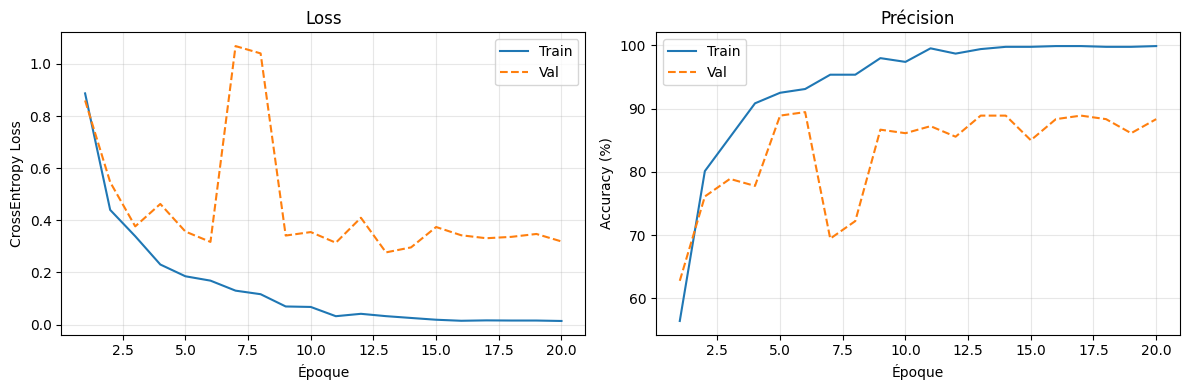

⚠️  Surapprentissage détecté — essayez + de Dropout ou + de données


In [15]:
# ✅ Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, 21)
axes[0].plot(epochs, history['tl'], label='Train')
axes[0].plot(epochs, history['vl'], '--', label='Val')
axes[0].set(xlabel='Époque', ylabel='CrossEntropy Loss', title='Loss')
axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(epochs, [a*100 for a in history['ta']], label='Train')
axes[1].plot(epochs, [a*100 for a in history['va']], '--', label='Val')
axes[1].set(xlabel='Époque', ylabel='Accuracy (%)', title='Précision')
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# Diagnostic automatique
gap = history['vl'][-1] - history['tl'][-1]
if gap > 0.1 * history['vl'][-1]:
    print('⚠️  Surapprentissage détecté — essayez + de Dropout ou + de données')
elif history['tl'][-1] > 0.8:
    print('⚠️  Sous-apprentissage — essayez un réseau plus profond ou lr plus élevé')
else:
    print('✅ Convergence satisfaisante')

In [16]:

# ✅ Évaluation finale sur le test set
model.load_state_dict(torch.load('/tmp/cnn_p1_best.pt'))
tl, ta = run_epoch(model, test_ld, None, crit, DEVICE, train=False)
print(f'TEST : Loss={tl:.4f}  Accuracy={ta*100:.1f}%')

TEST : Loss=0.2048  Accuracy=92.2%


## 5. Analyse des résultats

Répondez aux questions suivantes :
1. Quelle accuracy obtenez-vous sur le test set ?
2. Les courbes montrent-elles du surapprentissage ? Comment le diagnostiquer ?
3. Que montrent les feature maps de la Conv1 ?

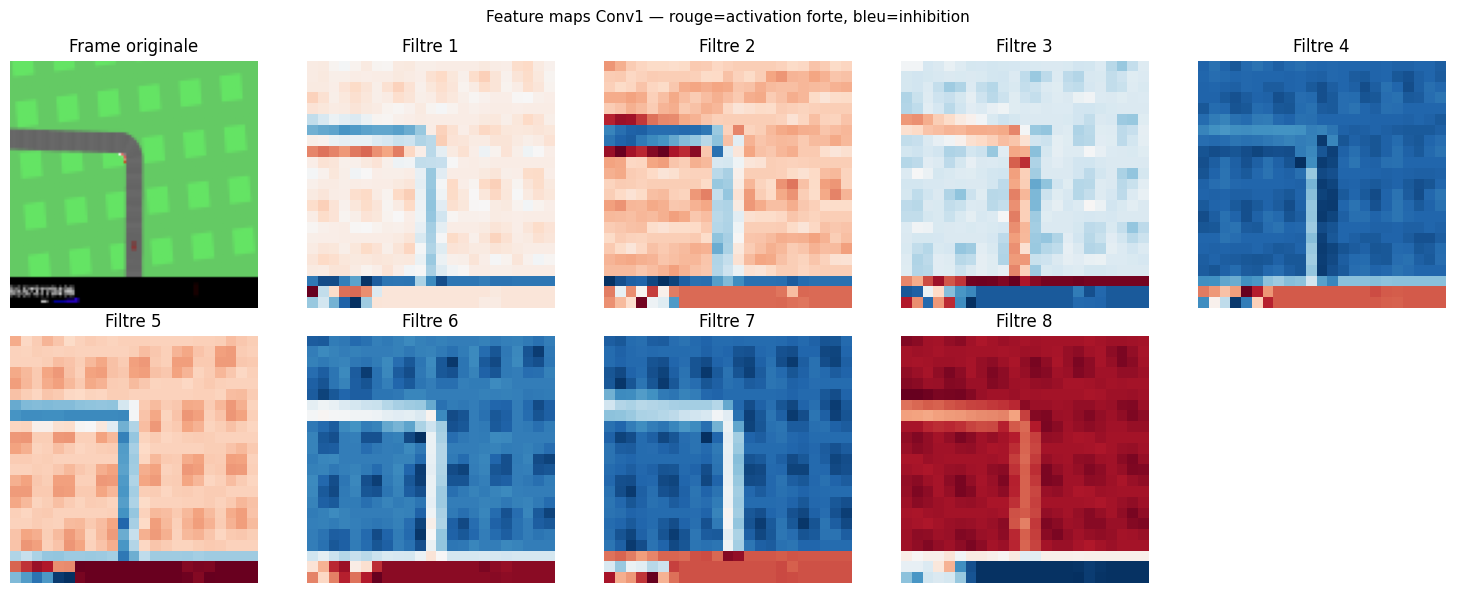

→ Chaque filtre a appris à détecter un type de pattern différent dans l'image


In [17]:
# TODO : Visualisez les feature maps de la 1ère couche convolutionnelle
# Utilisez register_forward_hook pour capturer les activations
model.eval()
frame, label = test_ds[0]
xin = frame.unsqueeze(0).to(DEVICE)

# Hook pour capturer les activations de conv1
acts_c1 = {}
h = model.conv1.register_forward_hook(lambda m,i,o: acts_c1.update({'v': o.detach().cpu()}))
with torch.no_grad(): model(xin)
h.remove()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0,0].imshow(frame.permute(1,2,0).numpy()); axes[0,0].set_title('Frame originale'); axes[0,0].axis('off')
fmaps = acts_c1['v'][0]
for i, ax in enumerate(axes.flat[1:]):
    if i < fmaps.shape[0]:
        ax.imshow(fmaps[i].numpy(), cmap='RdBu_r')
        ax.set_title(f'Filtre {i+1}')
    ax.axis('off')
plt.suptitle('Feature maps Conv1 — rouge=activation forte, bleu=inhibition', fontsize=11)
plt.tight_layout(); plt.show()
print('→ Chaque filtre a appris à détecter un type de pattern différent dans l\'image')

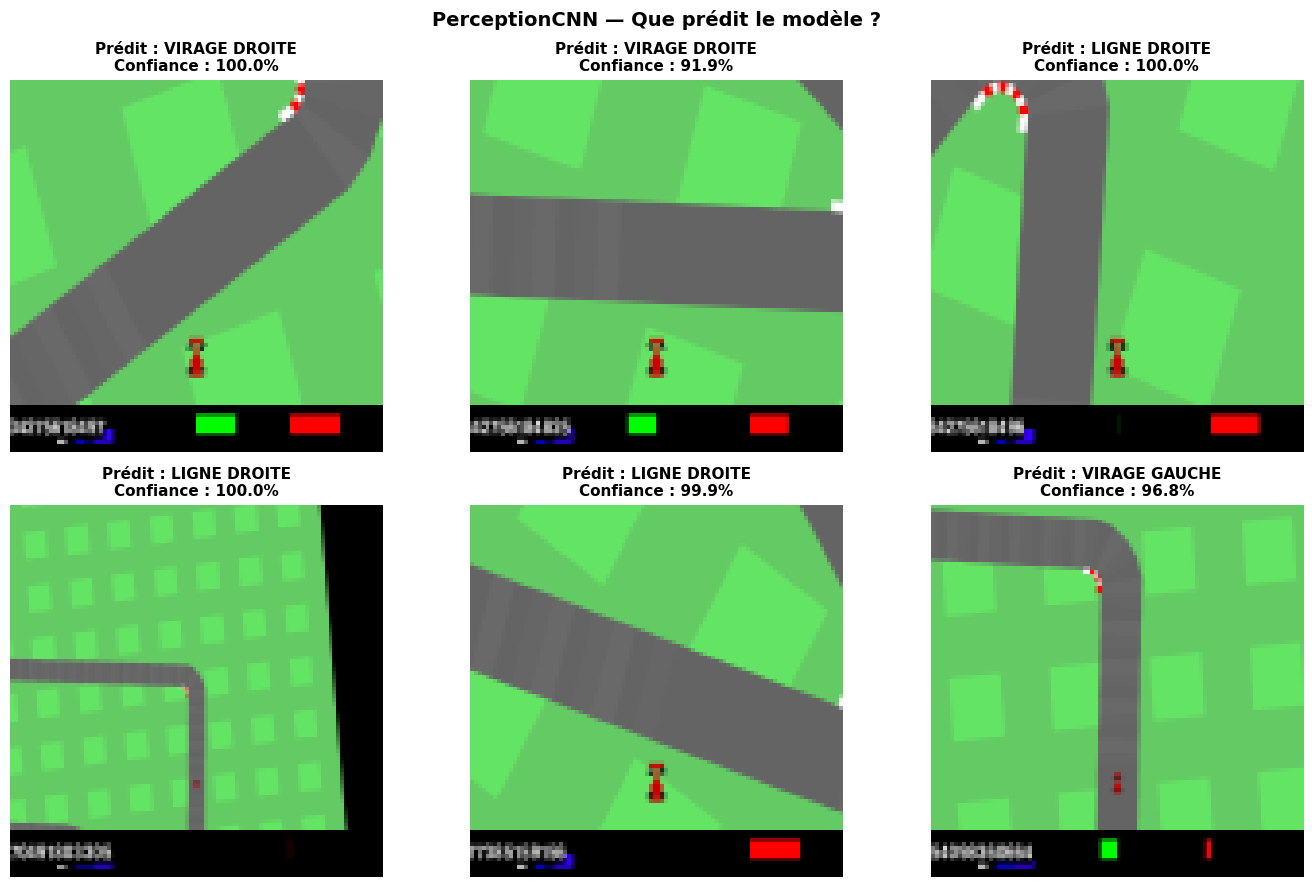

In [25]:
# ==============================
# BONUS v2 — Tirage aléatoire de frames du dataset
# ==============================
import random

model.eval()
CLASS_NAMES = ['LIGNE DROITE', 'VIRAGE GAUCHE', 'VIRAGE DROITE']

# Tirer 6 frames aléatoires du test set
indices = random.sample(range(len(test_ds)), 6)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('PerceptionCNN — Que prédit le modèle ?', fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flat, indices):
    X_tensor, true_label = test_ds[idx]

    with torch.no_grad():
        probs = torch.softmax(model(X_tensor.unsqueeze(0).to(DEVICE)), dim=1)[0]
        pred  = probs.argmax().item()

    probs_list = np.array(probs.tolist())

    # Reconstruire l'image originale (dénormaliser)
    img = np.array((X_tensor.permute(1, 2, 0) * 255).tolist(), dtype=np.uint8)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f'Prédit : {CLASS_NAMES[pred]}\nConfiance : {probs_list[pred]*100:.1f}%',
        fontsize=11, fontweight='bold', color='black'
    )

    # Petites barres de confiance sous l'image
    for j, (name, prob, color) in enumerate(zip(
        CLASS_NAMES, probs_list, ['steelblue', 'coral', 'green']
    )):
        ax.text(2, 88 + j*0, '', fontsize=7)  # placeholder

plt.tight_layout()
plt.show()